## Comparative Study of Loss Functions in PyTorch:
## BCEWithLogitsLoss vs BCELoss vs CrossEntropyLoss

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch

In [3]:
import torch.nn as nn
!pip install torchviz
!apt-get install -y graphviz
from torchviz import make_dot




graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 138 not upgraded.


# Multi-Class Classification using CrossEntropyLoss with Train-Test Split

In [4]:
# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/iris/Iris.csv")
df = df.drop("Id", axis=1)
print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


In [5]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [6]:
# Encode Labels
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

In [7]:
df['Species'].unique()

array([0, 1, 2])

In [8]:
# Split Data
X = df.drop('Species', axis=1).values
y = df['Species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
print(X_train[1:5], X_test[1:5], y_train[1:5], y_test[1:5])

[[5.7 4.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]
 [4.8 3.4 1.6 0.2]
 [4.4 3.2 1.3 0.2]] [[5.7 3.8 1.7 0.3]
 [7.7 2.6 6.9 2.3]
 [6.  2.9 4.5 1.5]
 [6.8 2.8 4.8 1.4]] [0 1 0 0] [0 2 1 1]


In [10]:
# Convert to Tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)


# The Problematic Scenario:
#datatype of tensor
# You are using nn.CrossEntropyLoss() but your y values are floats (Ex: 1.0 instead of 1).
# Your model weights are float32, but your input data X was converted from a NumPy array without specifying the dtype, making it a double.

In [11]:
class ANNBasics(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(4, 8)
        # 4 input feature and 8 hidden neuron
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 3)
        # from 8 hidden to 3 output

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


# No softmax here! (important gotcha)
# CrossEntropyLoss already includes: Softmax + Log

In [12]:
# Loss + Optimizer
model = ANNBasics()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [13]:
print(model)

ANNBasics(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=3, bias=True)
)


In [14]:
# Check total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(total_params)

67


Loss: 1.2795441150665283
Accuracy: 0.36666666666666664


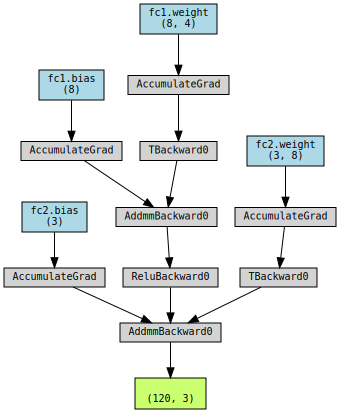

In [15]:
# Forward
outputs = model(X_train)

graph = make_dot(outputs, params=dict(model.named_parameters()))
# graph.render("model_graph", format="png") # Saves as a PNG file

# Loss
loss = criterion(outputs, y_train)

# Backward
optimizer.zero_grad()
loss.backward()

print(f"Loss: {loss.item()}")


with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

    accuracy = (predicted == y_test).sum().item() / len(y_test)

print("Accuracy:", accuracy)
# print(param.grad)
make_dot(outputs, params=dict(list(model.named_parameters())))
graph

In [16]:
epochs = 50

for epoch in range(epochs):
    
    # ===== TRAINING =====
    model.train()

    # Forward
    outputs = model(X_train)

    # Loss
    loss = criterion(outputs, y_train)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # TRAIN ACCURACY 
    _, train_pred = torch.max(outputs, 1)
    train_acc = (train_pred == y_train).sum().item() / len(y_train)

    # VALIDATION 
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        _, val_pred = torch.max(val_outputs, 1)
        val_acc = (val_pred == y_test).sum().item() / len(y_test)

    # PRINT
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/50 | Loss: 1.2795 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 2/50 | Loss: 1.2633 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 3/50 | Loss: 1.2488 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 4/50 | Loss: 1.2358 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 5/50 | Loss: 1.2241 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 6/50 | Loss: 1.2135 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 7/50 | Loss: 1.2039 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 8/50 | Loss: 1.1951 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 9/50 | Loss: 1.1870 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 10/50 | Loss: 1.1796 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 11/50 | Loss: 1.1727 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 12/50 | Loss: 1.1663 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 13/50 | Loss: 1.1603 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 14/50 | Loss: 1.1548 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 15/50 | Loss: 1.1496 | Train Acc: 0.3250 | Val Acc: 0.3667
Epoch 16/50 | Loss: 1.1447 | Train

# Binary Classification using BCEWithLogitsLoss with Mini-Batch Training

In [17]:
from torch.utils.data import TensorDataset, DataLoader

In [18]:
# Load Dataset
df1 = pd.read_csv("/kaggle/input/datasets/organizations/uciml/iris/Iris.csv")
df1 = df1.drop("Id", axis=1)

# Binary target: Setosa = 0, Others = 1
df1['Species'] = df1['Species'].apply(lambda x: 0 if x == "Iris-setosa" else 1)
df1.head(-5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
140,6.7,3.1,5.6,2.4,1
141,6.9,3.1,5.1,2.3,1
142,5.8,2.7,5.1,1.9,1
143,6.8,3.2,5.9,2.3,1


In [19]:
X = df1.drop('Species', axis=1).values
y = df1['Species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

# BCE expects float + shape (N,1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
print(y_train_tensor[1:5])

# .view(-1, 1) and .unsqueeze(1) are often used to achieve the exact same result, but they "think" about the problem differently.

tensor([[0.],
        [1.],
        [0.],
        [0.]])


In [21]:
# Dataset + DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [22]:
class ANNBasics1(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)  #single output

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x  # logits

In [23]:
model = ANNBasics1()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [24]:
# Training Loop (Batch-wise)
epochs = 10

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Convert logits → probabilities
        probs = torch.sigmoid(outputs)

        # Convert to 0/1
        preds = (probs >= 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total


    # ===== VALIDATION =====
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Loss: 6.2143 | Train Acc: 0.2583 | Val Acc: 0.6667
Epoch 2 | Loss: 5.3748 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 3 | Loss: 5.0935 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 4 | Loss: 4.9441 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 5 | Loss: 4.9190 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 6 | Loss: 4.8201 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 7 | Loss: 4.7760 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 8 | Loss: 4.9086 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 9 | Loss: 4.8667 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 10 | Loss: 4.7052 | Train Acc: 0.6667 | Val Acc: 0.6667


# Binary Classification using BCELoss with Mini-Batch Training

In [25]:
df2 = pd.read_csv("/kaggle/input/datasets/organizations/uciml/iris/Iris.csv")
df2 = df2.drop("Id", axis=1)

# Binary: Setosa = 0, Others = 1
df2['Species'] = df2['Species'].apply(lambda x: 0 if x == "Iris-setosa" else 1)

X = df2.drop('Species', axis=1).values
y = df2['Species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

# BCELoss needs float + (N,1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [27]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [28]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()   # REQUIRED

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)  #convert logits → probability
        return x

In [29]:
model = ANN()

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [30]:
# Training Loop (Batch-wise)
epochs = 10

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        outputs = model(X_batch)  # already probabilities

        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Predictions (no sigmoid needed now)
        preds = (outputs >= 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total


    # ===== VALIDATION =====
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)

            preds = (outputs >= 0.5).float()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Loss: 7.9118 | Train Acc: 0.1167 | Val Acc: 0.5000
Epoch 2 | Loss: 5.6351 | Train Acc: 0.6500 | Val Acc: 0.6667
Epoch 3 | Loss: 5.0867 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 4 | Loss: 4.8985 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 5 | Loss: 4.6184 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 6 | Loss: 4.3369 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 7 | Loss: 4.3098 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 8 | Loss: 4.1089 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 9 | Loss: 3.8871 | Train Acc: 0.6667 | Val Acc: 0.6667
Epoch 10 | Loss: 3.7202 | Train Acc: 0.6667 | Val Acc: 0.6667
